In [104]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import acf, pacf
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.ensemble import IsolationForest
import warnings


In [105]:
train = pd.read_csv("train.csv")
test = pd.read_csv("test.csv")
# df = train.__deepcopy__()

In [106]:
train.info()
train.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27181440 entries, 0 to 27181439
Data columns (total 20 columns):
 #   Column                Dtype  
---  ------                -----  
 0   module(equipment)     object 
 1   timestamp             int64  
 2   localtime             int64  
 3   operation             int64  
 4   voltageR              float64
 5   voltageS              float64
 6   voltageT              float64
 7   voltageRS             float64
 8   voltageST             float64
 9   voltageTR             float64
 10  currentR              float64
 11  currentS              float64
 12  currentT              float64
 13  activePower           float64
 14  powerFactorR          float64
 15  powerFactorS          float64
 16  powerFactorT          float64
 17  reactivePowerLagging  float64
 18  accumActiveEnergy     int64  
 19  datetime              object 
dtypes: float64(14), int64(4), object(2)
memory usage: 4.1+ GB


,timestamp,localtime,operation,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,currentR,currentS,currentT,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,accumActiveEnergy
count,2.718144e+07,2.718144e+07,27181440.0,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07,2.718144e+07
mean,1.738267e+12,2.024791e+13,1.0,2.149938e+02,2.149946e+02,2.149946e+02,3.723699e+02,3.723706e+02,3.723699e+02,1.749953e+01,1.749883e+01,1.750261e+01,3.009975e+03,9.246984e+01,9.247057e+01,9.246874e+01,6.019512e+02,7.055947e+06
std,3.016970e+09,3.929252e+09,0.0,2.901866e+00,2.902405e+00,2.902151e+00,3.572511e+00,3.572509e+00,3.572434e+00,7.217245e+00,7.217796e+00,7.216499e+00,7.171598e+02,4.405668e+00,4.405326e+00,4.405634e+00,2.290593e+02,2.787661e+06
min,1.733040e+12,2.024120e+13,1.0,1.901000e+02,1.901800e+02,1.901800e+02,3.310000e+02,3.299500e+02,3.305600e+02,5.000000e+00,5.000000e+00,5.000000e+00,8.644400e+02,6.000000e+01,6.000000e+01,6.000000e+01,9.010000e+01,1.129004e+06
25%,1.735654e+12,2.024123e+13,1.0,2.125000e+02,2.125000e+02,2.125000e+02,3.698400e+02,3.698400e+02,3.698400e+02,1.125000e+01,1.125000e+01,1.125000e+01,2.503800e+03,8.873000e+01,8.873000e+01,8.873000e+01,4.231600e+02,4.870391e+06
50%,1.738267e+12,2.025013e+13,1.0,2.150000e+02,2.150000e+02,2.150000e+02,3.723800e+02,3.723800e+02,3.723800e+02,1.750000e+01,1.750000e+01,1.750000e+01,3.009950e+03,9.249000e+01,9.249000e+01,9.249000e+01,5.739800e+02,7.055739e+06
75%,1.740881e+12,2.025030e+13,1.0,2.175000e+02,2.175000e+02,2.175000e+02,3.749200e+02,3.749200e+02,3.749200e+02,2.375000e+01,2.375000e+01,2.375000e+01,3.515940e+03,9.625000e+01,9.625000e+01,9.624000e+01,7.553900e+02,9.241356e+06
max,1.743491e+12,2.025033e+13,1.0,2.200000e+02,2.200000e+02,2.200000e+02,3.810400e+02,3.810400e+02,3.810400e+02,3.000000e+01,3.000000e+01,3.000000e+01,5.220930e+03,1.000000e+02,1.000000e+02,1.000000e+02,1.550630e+03,1.334350e+07


In [107]:
# # time stamp 컬럼 삭제 및 localtime을 datetime 형식으로 변환
train = train.drop(columns=['timestamp'])
# train['localtime'] = pd.to_datetime(train['localtime'], format='%Y%m%d%H%M%S')

test = test.drop(columns=['timestamp'])
# test['localtime'] = pd.to_datetime(test['localtime'], format='%Y%m%d%H%M%S')

In [108]:
train['accumActiveEnergy_kwh'] = train['accumActiveEnergy'] / 1000
test['accumActiveEnergy_kwh'] = test['accumActiveEnergy'] / 1000

In [109]:
train['current_mean'] = train[['currentR', 'currentS', 'currentT']].mean(axis=1)
train['current_std'] = train[['currentR', 'currentS', 'currentT']].std(axis=1)


test['current_mean'] = test[['currentR', 'currentS', 'currentT']].mean(axis=1)
test['current_std'] = test[['currentR', 'currentS', 'currentT']].std(axis=1)

In [110]:
# train = train.drop(columns=['localtime','accumActiveEnergy','operation','currentR', 'currentS', 'currentT'])
# test = test.drop(columns=['localtime','accumActiveEnergy','operation','currentR', 'currentS', 'currentT'])

In [111]:
train['powerFactorR'] /= 100
train['powerFactorS'] /= 100
train['powerFactorT'] /= 100

test['powerFactorR'] /= 100
test['powerFactorS'] /= 100
test['powerFactorT'] /= 100

In [112]:
train.head()

,module(equipment),voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,activePower,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,datetime,accumActiveEnergy_kwh,current_mean,current_std
0,1(PM-3),214.38,214.45,219.10,371.37,375.45,375.39,2961.61,0.8731,0.9971,0.8945,785.37,2024-12-01 00:00:00,1955.004,17.113333,3.068425
1,1(PM-3),214.05,211.74,218.68,368.73,372.74,374.74,3017.48,0.8754,0.8767,0.9417,376.57,2024-12-01 00:00:05,1955.008,17.506667,9.515442
2,1(PM-3),215.79,214.92,211.10,373.00,368.94,369.69,2408.01,0.8546,0.9900,0.9445,296.08,2024-12-01 00:00:10,1955.011,14.070000,0.693470
3,1(PM-3),210.39,214.92,215.57,368.32,372.80,368.89,3289.33,0.8524,0.9953,0.9561,488.48,2024-12-01 00:00:15,1955.016,19.303333,11.697950
4,1(PM-3),216.71,216.37,215.65,375.05,374.13,374.43,3069.31,0.9281,0.9126,0.9182,604.70,2024-12-01 00:00:20,1955.020,17.743333,10.670358


In [113]:
df_1 = train[train['module(equipment)'] == '1(PM-3)']
df_2 = train[train['module(equipment)'] == '2(L-1전등)']
df_15 = train[train['module(equipment)'] == '15(예비건조기)']
df_16 = train[train['module(equipment)'] == '16(호이스트)']

df_12 = train[train['module(equipment)'] == '12(4호기)']
df_13 = train[train['module(equipment)'] == '13(3호기)']
df_14 = train[train['module(equipment)'] == '14(2호기)']
df_17 = train[train['module(equipment)'] == '17(6호기)']

df_3 = train[train['module(equipment)'] == '3(분쇄기(2))']
df_4 = train[train['module(equipment)'] == '4(분쇄기(1))']
df_5 = train[train['module(equipment)'] == '5(좌측분전반)']
df_11 = train[train['module(equipment)'] == '11(우측분전반1)']
df_18 = train[train['module(equipment)'] == '18(우측분전반2)']

train_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [114]:
df_1 = test[test['module(equipment)'] == '1(PM-3)']
df_2 = test[test['module(equipment)'] == '2(L-1전등)']
df_15 = test[test['module(equipment)'] == '15(예비건조기)']
df_16 = test[test['module(equipment)'] == '16(호이스트)']

df_12 = test[test['module(equipment)'] == '12(4호기)']
df_13 = test[test['module(equipment)'] == '13(3호기)']
df_14 = test[test['module(equipment)'] == '14(2호기)']
df_17 = test[test['module(equipment)'] == '17(6호기)']

df_3 = test[test['module(equipment)'] == '3(분쇄기(2))']
df_4 = test[test['module(equipment)'] == '4(분쇄기(1))']
df_5 = test[test['module(equipment)'] == '5(좌측분전반)']
df_11 = test[test['module(equipment)'] == '11(우측분전반1)']
df_18 = test[test['module(equipment)'] == '18(우측분전반2)']

test_list = [df_1, df_2, df_3, df_4, df_5, df_11, df_12, df_13, df_14, df_15, df_16, df_17, df_18]

In [ ]:
def create_enhanced_time_features(timestamps):
    """시간 기반 특성을 더욱 풍부하게 생성"""
    ts = pd.to_datetime(timestamps)
    df = pd.DataFrame()
    
    # 기본 시간 특성
    df['hour'] = ts.dt.hour
    df['dayofweek'] = ts.dt.dayofweek
    df['month'] = ts.dt.month
    df['day'] = ts.dt.day
    
    # 순환적 특성 (사인/코사인)
    df['hour_sin'] = np.sin(2 * np.pi * ts.dt.hour / 24)
    df['hour_cos'] = np.cos(2 * np.pi * ts.dt.hour / 24)
    df['day_sin'] = np.sin(2 * np.pi * ts.dt.dayofweek / 7)
    df['day_cos'] = np.cos(2 * np.pi * ts.dt.dayofweek / 7)
    
    # 업무/비업무 시간 구분
    df['is_business_hour'] = ((ts.dt.hour >= 9) & (ts.dt.hour <= 18) & 
                              (ts.dt.dayofweek < 5)).astype(int)
    df['is_weekend'] = (ts.dt.dayofweek >= 5).astype(int)
    df['is_peak_hour'] = ((ts.dt.hour >= 10) & (ts.dt.hour <= 16)).astype(int)
    
    return df

In [ ]:
def create_rolling_features(data, windows=[3, 6, 12, 24]):
    """다양한 시간 창에서의 롤링 통계 특성 생성"""
    features = pd.DataFrame(index=data.index)
    
    for window in windows:
        # 전력 관련 주요 컬럼들에 대해
        for col in ['voltageR', 'voltageS', 'voltageT', 'currentR', 'currentS', 'currentT']:
            features[f'{col}_mean_{window}h'] = data[col].rolling(window).mean()
            features[f'{col}_std_{window}h'] = data[col].rolling(window).std()
            features[f'{col}_min_{window}h'] = data[col].rolling(window).min()
            features[f'{col}_max_{window}h'] = data[col].rolling(window).max()
    
    return features

In [ ]:
def create_electrical_features(data):
    """전력공학적 의미가 있는 파생 특성 생성"""
    features = pd.DataFrame(index=data.index)
    
    # 전압 불균형
    features['voltage_imbalance'] = (
        (data['voltageR'] + data['voltageS'] + data['voltageT']) / 3 -
        np.sqrt((data['voltageR']**2 + data['voltageS']**2 + data['voltageT']**2) / 3)
    )
    
    # 전류 불균형
    features['current_imbalance'] = (
        data[['currentR', 'currentS', 'currentT']].std(axis=1)
    )
    
    # 역률 평균 및 편차
    features['power_factor_avg'] = data[['powerFactorR', 'powerFactorS', 'powerFactorT']].mean(axis=1)
    features['power_factor_std'] = data[['powerFactorR', 'powerFactorS', 'powerFactorT']].std(axis=1)
    
    # 전압-전류 관계
    features['voltage_current_ratio'] = (
        (data['voltageR'] + data['voltageS'] + data['voltageT']) / 
        (data['currentR'] + data['currentS'] + data['currentT'] + 1e-8)
    )
    
    # 무효전력 대비 유효전력 비율
    features['active_reactive_ratio'] = data['activePower'] / (data['reactivePowerLagging'] + 1e-8)
    
    return features

In [ ]:
def create_equipment_interaction_features(all_equipment_data):
    """장비 간 상호작용을 고려한 특성 생성"""
    # 전체 설비의 총 전력 소비량
    total_power = sum([df['activePower'] for df in all_equipment_data])
    
    interaction_features = []
    for i, data in enumerate(all_equipment_data):
        features = pd.DataFrame(index=data.index)
        
        # 해당 장비의 전체 대비 비중
        features['power_ratio_to_total'] = data['activePower'] / (total_power + 1e-8)
        
        # 다른 장비들과의 상관관계 (sliding window)
        for j, other_data in enumerate(all_equipment_data):
            if i != j:
                features[f'correlation_with_eq_{j}'] = (
                    data['activePower'].rolling(24).corr(other_data['activePower'].rolling(24))
                )
        
        interaction_features.append(features)
    
    return interaction_features

In [ ]:
def advanced_outlier_treatment(data, method='isolation_forest'):
    """다양한 이상치 탐지 및 처리 방법"""
    if method == 'isolation_forest':
        from sklearn.ensemble import IsolationForest
        
        # 각 수치 컬럼별로 이상치 탐지
        numeric_cols = data.select_dtypes(include=[np.number]).columns
        outlier_mask = pd.DataFrame(False, index=data.index, columns=numeric_cols)
        
        for col in numeric_cols:
            iso_forest = IsolationForest(contamination=0.1, random_state=42)
            outliers = iso_forest.fit_predict(data[[col]].fillna(0))
            outlier_mask[col] = (outliers == -1)
            
            # 이상치를 rolling median으로 대체
            rolling_median = data[col].rolling(window=24, center=True).median()
            data.loc[outlier_mask[col], col] = rolling_median[outlier_mask[col]]
    
    return data

In [ ]:
def feature_selection_pipeline(X, y, method='mutual_info'):
    """피처 중요도 기반 선택"""
    from sklearn.feature_selection import mutual_info_regression, SelectKBest
    from sklearn.ensemble import RandomForestRegressor
    
    if method == 'mutual_info':
        selector = SelectKBest(score_func=mutual_info_regression, k=20)
        X_selected = selector.fit_transform(X, y)
        selected_features = X.columns[selector.get_support()]
        
    elif method == 'random_forest':
        rf = RandomForestRegressor(n_estimators=100, random_state=42)
        rf.fit(X, y)
        feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
        selected_features = feature_importance.nlargest(20).index
        X_selected = X[selected_features]
    
    return X_selected, selected_features

In [ ]:
def adaptive_scaling(train_data, test_data, method='robust'):
    """적응적 스케일링"""
    if method == 'robust':
        from sklearn.preprocessing import RobustScaler
        scaler = RobustScaler()
    elif method == 'quantile':
        from sklearn.preprocessing import QuantileTransformer
        scaler = QuantileTransformer(output_distribution='normal')
    
    # 장비별로 다른 스케일링 적용 가능
    train_scaled = scaler.fit_transform(train_data)
    test_scaled = scaler.transform(test_data)
    
    return train_scaled, test_scaled, scaler

In [ ]:
def comprehensive_preprocessing_pipeline(train_list, test_list, train_y, train_timestamps, test_timestamps):
    """통합 전처리 파이프라인"""
    
    processed_train = []
    processed_test = []
    
    for i in range(len(train_list)):
        print(f"Processing equipment {i+1}/13...")
        
        # 1. 시간 특성 추가
        time_features_train = create_enhanced_time_features(train_timestamps[i])
        time_features_test = create_enhanced_time_features(test_timestamps[i])
        
        # 2. 롤링 통계 특성
        rolling_features_train = create_rolling_features(train_list[i])
        rolling_features_test = create_rolling_features(test_list[i])
        
        # 3. 전력공학적 특성
        electrical_features_train = create_electrical_features(train_list[i])
        electrical_features_test = create_electrical_features(test_list[i])
        
        # 4. 특성 결합
        X_train = pd.concat([train_list[i], time_features_train, 
                           rolling_features_train, electrical_features_train], axis=1)
        X_test = pd.concat([test_list[i], time_features_test, 
                          rolling_features_test, electrical_features_test], axis=1)
        
        # 5. 이상치 처리
        X_train = advanced_outlier_treatment(X_train)
        X_test = advanced_outlier_treatment(X_test)
        
        # 6. 피처 선택
        X_train_selected, selected_features = feature_selection_pipeline(
            X_train.fillna(0), train_y[i]
        )
        X_test_selected = X_test[selected_features].fillna(0)
        
        # 7. 스케일링
        X_train_scaled, X_test_scaled, scaler = adaptive_scaling(
            X_train_selected, X_test_selected, method='robust'
        )
        
        processed_train.append(pd.DataFrame(X_train_scaled, columns=selected_features))
        processed_test.append(pd.DataFrame(X_test_scaled, columns=selected_features))
    
    return processed_train, processed_test

In [115]:
for df in train_list:
    df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)

for df in test_list:
    df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)


C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\2929203354.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\2929203354.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['delta_energy'] = df['accumActiveEnergy_kwh'].diff().fillna(0)
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\2929203354.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a 

In [116]:
train_y = []
train_timestamps = []
for i in range(len(train_list)):
    train_y.append(train_list[i]["activePower"])
    train_list[i] = train_list[i].drop(columns=['activePower','accumActiveEnergy_kwh'])

    train_timestamps.append(train_list[i]["datetime"])
    train_list[i] = train_list[i].drop(columns=['datetime'])
    train_list[i] = train_list[i].drop(columns=['module(equipment)'])

In [117]:
test_y = []
test_timestamps = []
for i in range(len(test_list)):
    test_y.append(test_list[i]["activePower"])
    test_list[i] = test_list[i].drop(columns=['activePower','accumActiveEnergy_kwh'])

    test_timestamps.append(test_list[i]["datetime"])
    test_list[i] = test_list[i].drop(columns=['datetime'])
    test_list[i] = test_list[i].drop(columns=['module(equipment)'])

In [ ]:
# 전처리 파이프라인 적용
processed_train, processed_test = comprehensive_preprocessing_pipeline(
    train_list, 
    test_list,
    train_y,
    train_timestamps,
    test_timestamps
)


In [118]:
train_y[0]

0          2961.61
1          3017.48
2          2408.01
3          3289.33
4          3069.31
            ...   
2090875    3832.06
2090876    3289.76
2090877    3162.92
2090878    4226.72
2090879    3687.07
Name: activePower, Length: 2090880, dtype: float64

In [119]:
train_list[0]

,voltageR,voltageS,voltageT,voltageRS,voltageST,voltageTR,powerFactorR,powerFactorS,powerFactorT,reactivePowerLagging,current_mean,current_std,delta_energy
0,214.38,214.45,219.10,371.37,375.45,375.39,0.8731,0.9971,0.8945,785.37,17.113333,3.068425,0.000
1,214.05,211.74,218.68,368.73,372.74,374.74,0.8754,0.8767,0.9417,376.57,17.506667,9.515442,0.004
2,215.79,214.92,211.10,373.00,368.94,369.69,0.8546,0.9900,0.9445,296.08,14.070000,0.693470,0.003
3,210.39,214.92,215.57,368.32,372.80,368.89,0.8524,0.9953,0.9561,488.48,19.303333,11.697950,0.005
4,216.71,216.37,215.65,375.05,374.13,374.43,0.9281,0.9126,0.9182,604.70,17.743333,10.670358,0.004
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2090875,214.30,216.68,213.96,373.23,372.93,370.87,0.9364,0.9925,0.9076,642.09,22.296667,4.036017,0.005
2090876,212.76,214.61,218.61,370.10,375.16,373.57,0.9640,0.9383,0.8861,587.26,19.023333,8.054765,0.005
2090877,216.86,212.30,218.13,371.65,372.76,376.70,0.9023,0.9841,0.9604,449.31,18.416667,11.131439,0.004
2090878,210.16,218.17,212.24,370.93,372.74,365.80,0.9647,0.8974,0.8976,804.07,24.763333,3.679543,0.006


In [120]:
def replace_outliers_with_mean_all_columns(df, max_iter = 1):
    """
    데이터프레임의 모든 수치형 컬럼에 대해 IQR 기반 이상치를 평균값으로 대체
    """
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    for column in numeric_cols:
        for _ in range(max_iter):
            Q1 = df[column].quantile(0.25)
            Q3 = df[column].quantile(0.75)
            IQR = Q3 - Q1
            lower_bound = Q1 - 1.5 * IQR
            upper_bound = Q3 + 1.5 * IQR
            median_value = df[column].median()
            outliers = (df[column] < lower_bound) | (df[column] > upper_bound)
            if not outliers.any():
                break
            df.loc[outliers, column] = median_value

# 각 데이터프레임에 대해 모든 수치형 컬럼에 대해 이상치 대치 수행
for df in train_list:
    replace_outliers_with_mean_all_columns(df)

for df in test_list:
    replace_outliers_with_mean_all_columns(df)

C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  plt.tight_layout()
C:\Users\hoyeong\AppData\Local\Temp\ipykernel_15964\1973199651.py:10: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  plt.tight_l

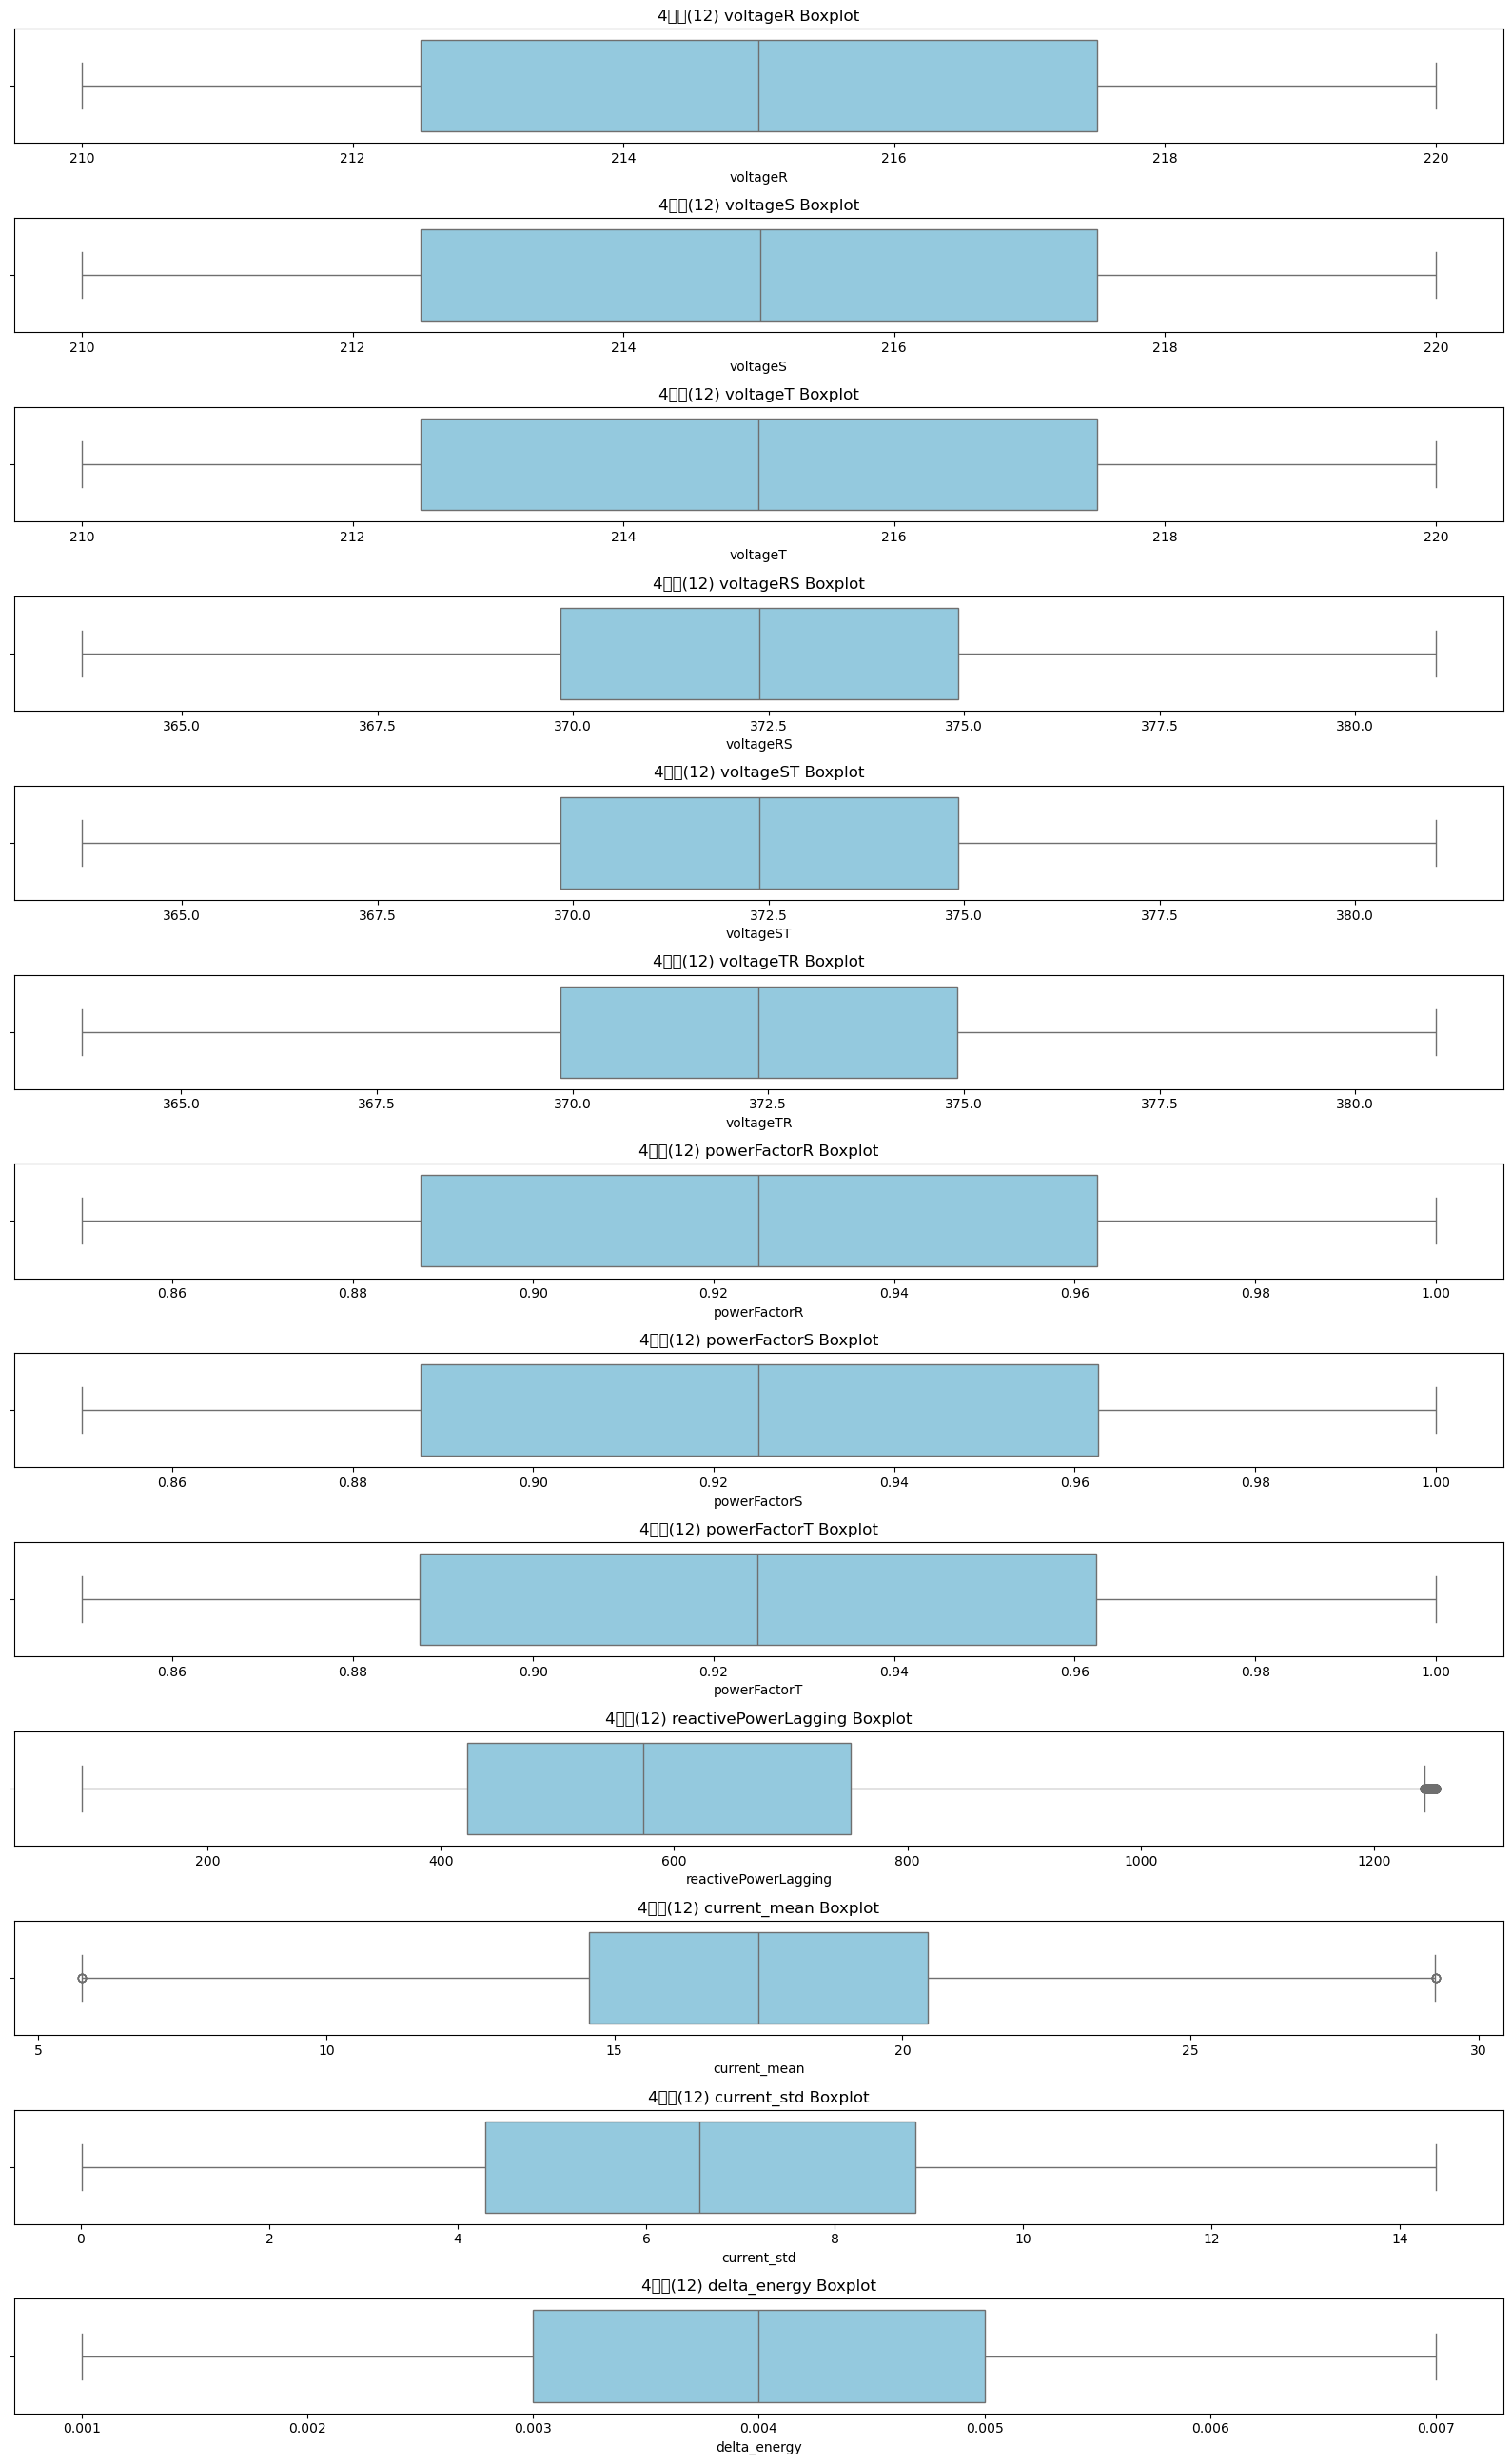

In [121]:
# 주요 수치형 변수 리스트
num_cols = train_list[0].select_dtypes(include=[np.number]).columns.tolist()

# 주요 수치형 변수별로 개별 박스플롯을 그리기
plt.figure(figsize=(16, 2 * len(num_cols)))
for i, col in enumerate(num_cols, 1):
    plt.subplot(len(num_cols), 1, i)
    sns.boxplot(x=train_list[0][col], color='skyblue')
    plt.title(f'4호기(12) {col} Boxplot')
    plt.tight_layout()
plt.show()

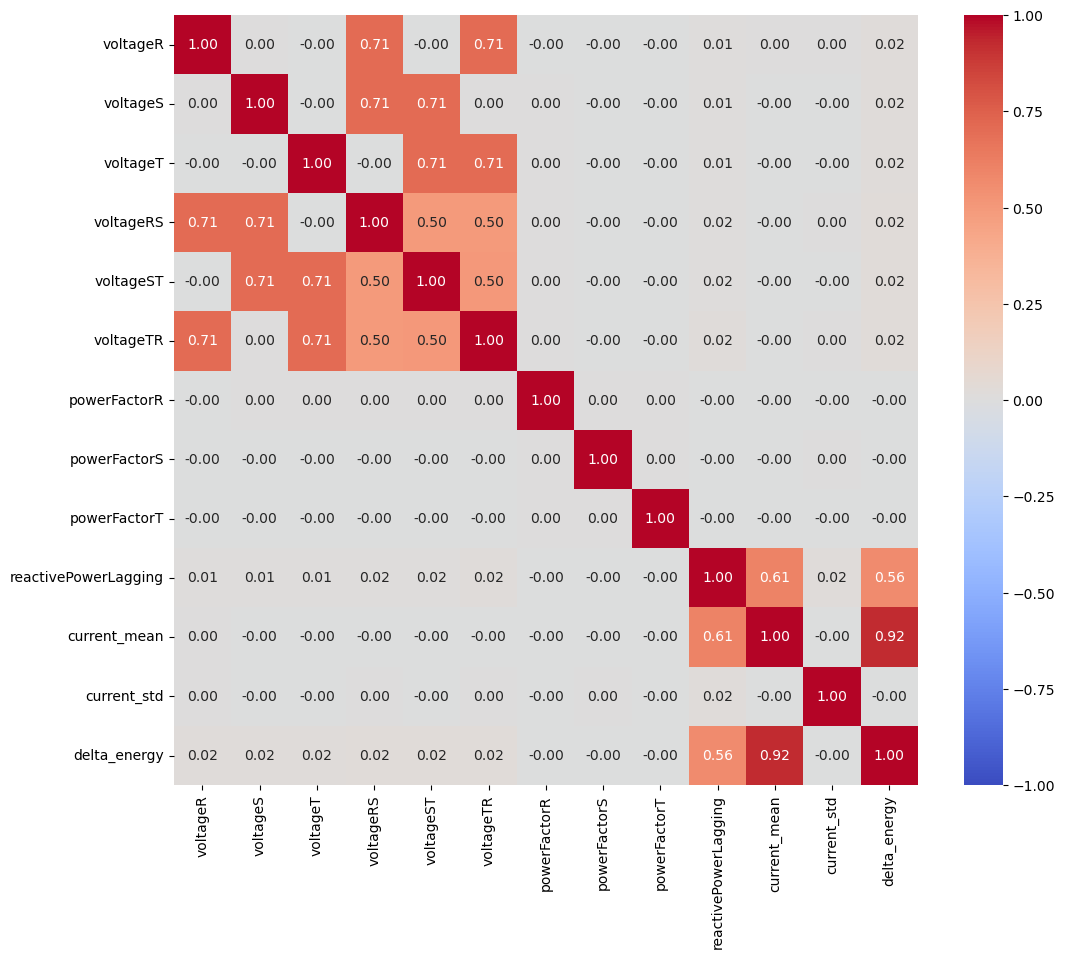

In [122]:
# 전체체 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.show()

C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44592 (\N{HANGUL SYLLABLE GI}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51452 (\N{HANGUL SYLLABLE JU}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\hoyeong\AppData\Roaming\Python\Python312\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 48320 (\N{HANGUL SYLLABLE

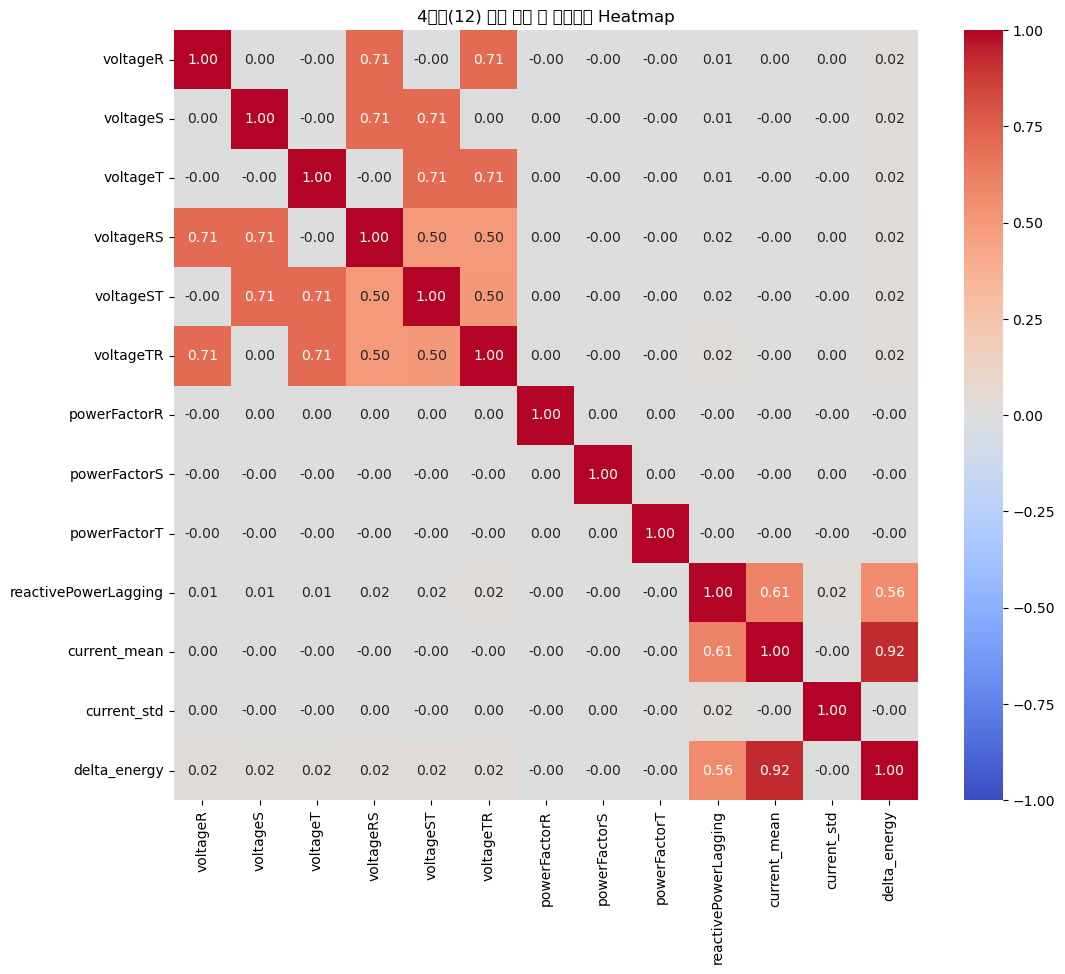

In [123]:
# 4호기(12) 주요 변수 간 상관관계 분석 및 시각화
corr = train_list[0][num_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("4호기(12) 주요 변수 간 상관관계 Heatmap")
plt.show()

In [124]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(X):
    # 다중 공선성이 높은 칼럼 자동 추출 (VIF 기준 10 이상)
    vif_data = pd.DataFrame()
    vif_data["feature"] = num_cols
    vif_data["VIF"] = [variance_inflation_factor(df_4[num_cols].dropna().values, i) for i in range(len(num_cols))]
    high_vif_cols = vif_data[vif_data["VIF"] >= 10]["feature"].tolist()

    print("다중 공선성이 높은 칼럼:", high_vif_cols)
    return high_vif_cols

In [125]:
# 다중 공선성이 높은 칼럼(PCA로 차원축소) 예시

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def pca_analysis(df,high_vif_cols):
    # 표준화
    scaler = StandardScaler()
    scaled = scaler.fit_transform(df[high_vif_cols])

    # PCA (설명분산 95%까지 유지)
    pca = PCA(n_components=0.95)
    pca_result = pca.fit_transform(scaled)

    print(f"PCA로 축소된 차원 수: {pca.n_components_}")
    # PCA 결과를 DataFrame으로 변환
    pca_df = pd.DataFrame(pca_result,
                          columns=[f'pca_{i+1}' for i in range(pca.n_components_)],
                          index=df[high_vif_cols].dropna().index)

    # VIF 낮은 칼럼만 따로 분리
    low_vif_cols = [col for col in df.columns if col not in high_vif_cols]
    df_low_vif = df[low_vif_cols].loc[df[high_vif_cols].dropna().index]

    # 낮은 VIF 칼럼 + PCA 주성분 결합
    df_final = pd.concat([df_low_vif.reset_index(drop=True), pca_df.reset_index(drop=True)], axis=1)

    return df_final 

In [126]:
# from sklearn.preprocessing import StandardScaler
# from sklearn.decomposition import PCA

# for i in range(len(train_list)):
#     print(f"\n📌 Dataset {i+1} PCA 처리 중...")

#     # 1. train/test 분리
#     train_df = train_list[i].copy()
#     test_df = test_list[i].copy()

#     # 2. VIF 높은 feature 추출 (train 기준)
#     num_cols = train_df.select_dtypes(include=[np.number]).columns.tolist()
#     df_4 = train_df  # calculate_vif 함수 내에서 사용되는 전역 이름
#     high_vif_cols = calculate_vif(train_df)

#     # 3. PCA 학습 (train 기준)
#     scaler_pca = StandardScaler()
#     train_scaled = scaler_pca.fit_transform(train_df[high_vif_cols])
#     pca = PCA(n_components=0.95)
#     train_pca_result = pca.fit_transform(train_scaled)
#     print(f"🔧 PCA로 축소된 차원 수: {pca.n_components_}")

#     # 4. PCA → DataFrame
#     pca_train_df = pd.DataFrame(train_pca_result,
#                                 columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
#                                 index=train_df.index)

#     # 5. low VIF 변수 결합 (train)
#     low_vif_cols = [col for col in train_df.columns if col not in high_vif_cols]
#     train_combined = pd.concat([train_df[low_vif_cols].reset_index(drop=True),
#                                 pca_train_df.reset_index(drop=True)], axis=1)

#     # 6. test에도 동일한 PCA 구성 적용
#     test_scaled = scaler_pca.transform(test_df[high_vif_cols])
#     test_pca_result = pca.transform(test_scaled)
#     pca_test_df = pd.DataFrame(test_pca_result,
#                                columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
#                                index=test_df.index)

#     test_combined = pd.concat([test_df[low_vif_cols].reset_index(drop=True),
#                                pca_test_df.reset_index(drop=True)], axis=1)

#     # 7. 전체 정규화 (PCA + low-VIF 합친 후)
#     scaler_all = StandardScaler()
#     train_list[i] = pd.DataFrame(scaler_all.fit_transform(train_combined),
#                                  columns=train_combined.columns)
#     test_list[i] = pd.DataFrame(scaler_all.transform(test_combined),
#                                 columns=test_combined.columns)


In [127]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 적용할 PCA 대상 및 제외할 feature 목록
pca_features = [
    'voltageR', 'voltageS', 'voltageT',
    'voltageRS', 'voltageST', 'voltageTR',
    'powerFactorR', 'powerFactorS', 'powerFactorT',
    'current_mean', 'current_std'
]

non_pca_features = [
    'reactivePowerLagging', 'delta_energy'
]

for i in range(len(train_list)):
    print(f"\n📌 Dataset {i+1} PCA 처리 중...")

    # 1. train/test 분리
    train_df = train_list[i].copy()
    test_df = test_list[i].copy()

    # 2. PCA 학습 (train 기준)
    scaler_pca = StandardScaler()
    train_scaled = scaler_pca.fit_transform(train_df[pca_features])
    pca = PCA(n_components=0.95)
    train_pca_result = pca.fit_transform(train_scaled)
    print(f"🔧 PCA로 축소된 차원 수: {pca.n_components_}")

    # 3. PCA 결과 → DataFrame 변환
    pca_train_df = pd.DataFrame(train_pca_result,
                                columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
                                index=train_df.index)

    # 4. low-VIF (즉, non-PCA) feature와 결합
    train_combined = pd.concat([
        train_df[non_pca_features].reset_index(drop=True),
        pca_train_df.reset_index(drop=True)
    ], axis=1)

    # 5. test에도 동일한 PCA 구성 적용
    test_scaled = scaler_pca.transform(test_df[pca_features])
    test_pca_result = pca.transform(test_scaled)
    pca_test_df = pd.DataFrame(test_pca_result,
                               columns=[f'pca_{j+1}' for j in range(pca.n_components_)],
                               index=test_df.index)

    test_combined = pd.concat([
        test_df[non_pca_features].reset_index(drop=True),
        pca_test_df.reset_index(drop=True)
    ], axis=1)

    # 6. 전체 정규화 (PCA 결과 + 기타 변수 포함 전체에 대해)
    scaler_all = StandardScaler()
    train_list[i] = pd.DataFrame(
        scaler_all.fit_transform(train_combined),
        columns=train_combined.columns
    )
    test_list[i] = pd.DataFrame(
        scaler_all.transform(test_combined),
        columns=test_combined.columns
    )



📌 Dataset 1 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 2 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 3 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 4 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 5 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 6 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 7 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 8 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 9 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 10 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 11 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 12 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8

📌 Dataset 13 PCA 처리 중...
🔧 PCA로 축소된 차원 수: 8


In [128]:
train_list[0]

,reactivePowerLagging,delta_energy,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8
0,0.833915,-0.168159,-0.583635,1.277065,-0.343870,0.031484,0.058914,-0.568836,1.425587,1.943907
1,-0.990001,-0.168159,0.107692,1.419593,-0.996478,-1.408261,-0.395008,0.254950,-1.211388,0.005605
2,-1.349118,-1.097816,0.639074,-1.214345,0.123805,0.630114,-0.020519,0.308793,0.678121,2.965083
3,-0.490699,0.761498,0.825320,1.087433,0.834876,-0.784794,-1.796786,-1.939670,-0.649795,1.070479
4,0.027832,-0.168159,-0.746867,-0.265908,-0.015744,-0.676650,-0.728480,-0.328240,-0.324310,-0.904113
...,...,...,...,...,...,...,...,...,...,...
2090875,0.194652,0.761498,0.013669,-0.259431,0.681770,0.815587,0.753981,-1.458384,1.002148,0.592235
2090876,-0.049979,0.761498,-0.195264,1.461897,0.057004,0.054703,0.008433,-0.563791,0.817403,-1.053053
2090877,-0.665461,-0.168159,-0.456887,0.657741,-1.353316,0.018722,-1.592803,-1.505499,-0.572163,0.281188
2090878,0.917348,1.691155,0.885803,0.013582,2.040848,0.179799,2.157143,-0.539666,0.235605,-0.773171


In [129]:
test_list[0]

,reactivePowerLagging,delta_energy,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8
0,-1.515626,-0.168159,-1.062993,0.244742,-1.563005,-0.832316,-2.240023,-1.119807,1.161844,-0.197621
1,-0.751749,0.761498,-0.817285,0.383075,-2.365243,1.498869,-0.322569,-0.681602,-1.203276,-0.219380
2,1.390415,-0.168159,0.197875,0.305004,1.216919,-1.195463,1.292183,0.660819,-0.733964,0.117184
3,-1.101675,-0.168159,-0.704758,-0.108258,-0.902389,0.998980,-0.380733,1.013243,-1.260373,-0.568048
4,0.529543,0.761498,-0.989904,-1.890000,0.591636,-1.021208,-0.682701,-1.139166,-0.283826,0.398550
...,...,...,...,...,...,...,...,...,...,...
501116,0.276836,1.691155,-0.099040,1.035265,-1.480689,0.757011,1.030861,-1.557692,-0.402606,0.748114
501117,-0.700173,-1.097816,1.261983,-0.677048,1.811626,-0.534352,-1.133868,-0.052854,-0.028070,-0.545711
501118,-1.480111,-1.097816,-0.434654,0.987763,1.539817,0.245774,-0.045626,1.606237,1.697270,-0.668209
501119,-0.165624,1.691155,-1.609104,0.123165,-0.198772,-1.233840,1.772459,-1.006833,1.157103,1.580993


## Transformer

In [130]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import math

# ------------------------ GPU 설정 ------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("[Info] Using device:", device)

# ------------------------ Positional Encoding ------------------------
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=1000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len).unsqueeze(1).float()
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)  # (1, max_len, d_model)

    def forward(self, x):
        return x + self.pe[:, :x.size(1)].to(x.device)

# ------------------------ Transformer Model ------------------------
class TransformerPredictor(nn.Module):
    def __init__(self, input_size, seq_len, d_model=128, nhead=4, num_layers=4):
        super().__init__()
        self.input_proj = nn.Linear(input_size, d_model)
        self.pos_enc = PositionalEncoding(d_model, max_len=seq_len+672)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, batch_first=True)
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.attn_weights = nn.Linear(d_model, 1)
        self.fc_out = nn.Linear(d_model, 1)

    def forward(self, x):
        x = self.input_proj(x)
        x = self.pos_enc(x)
        x = self.encoder(x)  # shape: (B, T, d_model)
        attn = torch.softmax(self.attn_weights(x), dim=1)  # shape: (B, T, 1)
        x = (x * attn).sum(dim=1)  # attention pooling
        return self.fc_out(x)


# ------------------------ 시퀀스 생성 ------------------------
def create_sequences(X_df, y_series, seq_len=24):
    X, y = [], []
    for i in range(len(X_df) - seq_len):
        X.append(X_df.iloc[i:i+seq_len].values)
        y.append(y_series.iloc[i+seq_len])
    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    return torch.tensor(X), torch.tensor(y).unsqueeze(1)

# ------------------------ 학습 루프 ------------------------
def train_model(model, X_train, y_train, epochs=5, lr=1e-3, batch_size=256):
    model.to(device)
    model.train()
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    loader = DataLoader(TensorDataset(X_train, y_train), batch_size=batch_size, shuffle=True)

    for epoch in range(epochs):
        total_loss = 0
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        print(f"[Epoch {epoch+1}] Loss: {total_loss / len(loader.dataset):.4f}")

    return model

# ------------------------ Autoregressive 예측 ------------------------
def predict_autoregressive(model, seed_seq, steps=672):
    model.eval()
    generated = []
    current = seed_seq.clone().to(device)  # (1, seq_len, input_size)

    with torch.no_grad():
        for _ in range(steps):
            pred = model(current)  # (1, 1)
            next_input = current[:, -1:, :].clone()
            next_input[:, :, 0] = pred  # 🔁 첫 번째 feature만 activePower로 덮기
            current = torch.cat([current[:, 1:], next_input], dim=1)
            generated.append(pred.item())

    return generated

# ------------------------ 시간 파생 특성 ------------------------
def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
    timestamps = pd.to_datetime(timestamps, errors='coerce')
    return pd.DataFrame({
        'hour': timestamps.dt.hour,
        'dayofweek': timestamps.dt.dayofweek,
        'month': timestamps.dt.month,
        'is_weekend': (timestamps.dt.dayofweek >= 5).astype(int)
    })

# ------------------------ SMAPE ------------------------
def smape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
    return np.mean(diff) * 100


[Info] Using device: cuda


In [131]:
# ------------------------ 전체 실행 루프 (다중 feature → 단일 예측) ------------------------

results_all = []
mae_scores = []
rmse_scores = []
smape_scores = []
may_bills = []
may_carbons = []

seq_len = 24

for i in range(len(train_list)):
    print(f"\n========= Processing Dataset {i+1} =========")

    # 1. 학습 데이터
    X_train_df = pd.DataFrame(train_list[i], columns=train_list[i].columns).reset_index(drop=True)
    X_test_df = pd.DataFrame(test_list[i], columns=test_list[i].columns).reset_index(drop=True)

    y_train_series = train_y[i].reset_index(drop=True)
    y_test_series = test_y[i].reset_index(drop=True)

    ts_train = pd.to_datetime(train_timestamps[i].reset_index(drop=True))
    ts_test = pd.to_datetime(test_timestamps[i].reset_index(drop=True))

    # 🔹 1-1. 시간 파생 feature 추가
    time_feats_train = create_time_features(ts_train)
    time_feats_test = create_time_features(ts_test)

    # 🔹 1-2. 원본 feature에 시간 feature 결합
    X_train_df = pd.concat([X_train_df, time_feats_train], axis=1)
    X_test_df = pd.concat([X_test_df, time_feats_test], axis=1)

    # 🔹 1-2. 원본 feature에 시간 feature 결합
    X_train_df = pd.concat([X_train_df, time_feats_train], axis=1)
    X_test_df = pd.concat([X_test_df, time_feats_test], axis=1)

    # 3. 시퀀스 생성
    X_seq, y_seq = create_sequences(X_train_df, y_train_series, seq_len)
    X_seq, y_seq = X_seq.to(device), y_seq.to(device)

    # 4. 모델 정의 및 학습
    input_dim = X_seq.shape[2]
    model = TransformerPredictor(input_size=input_dim, seq_len=seq_len).to(device)
    model = train_model(model, X_seq, y_seq, epochs=3, lr=0.001, batch_size=512)

    # 5. 4월 성능 평가
    X_valid_seq, y_valid_seq = create_sequences(X_test_df, y_test_series, seq_len)
    valid_dataset = TensorDataset(X_valid_seq, y_valid_seq)
    valid_loader = DataLoader(valid_dataset, batch_size=256, shuffle=False)

    model.eval()
    y_valid_pred_all, y_valid_true_all = [], []

    with torch.no_grad():
        for xb, yb in valid_loader:
            xb = xb.to(device)
            preds = model(xb).squeeze().cpu().numpy()
            y_valid_pred_all.append(preds)
            y_valid_true_all.append(yb.squeeze().cpu().numpy())

    y_valid_pred = np.concatenate(y_valid_pred_all)
    y_valid_true = np.concatenate(y_valid_true_all)

    mae = mean_absolute_error(y_valid_true, y_valid_pred)
    rmse = root_mean_squared_error(y_valid_true, y_valid_pred)
    smape_val = smape(y_valid_true, y_valid_pred)

    print(f"[Validation - April] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

    mae_scores.append(1 / (1 + mae))
    rmse_scores.append(1 / (1 + rmse))
    smape_scores.append(1 / (1 + smape_val / 100))

    # 6. 5월 예측 (시드: 4월 마지막 24시간)
    last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)
    future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1h")
    preds = predict_autoregressive(model, last_seq, steps=len(future_ts))

    # 7. 요금 및 탄소량 계산
    agg_pow = np.sum(preds)
    may_bill = agg_pow * 180
    may_carbon = agg_pow * 0.424

    may_bills.append(may_bill)
    may_carbons.append(may_carbon)

    # 8. 결과 저장
    forecast_df = pd.DataFrame({
        'id': future_ts,
        'hourly_pow': preds,
        'agg_pow': [agg_pow] * len(future_ts),
        'may_bill': [may_bill] * len(future_ts),
        'may_carbon': [may_carbon] * len(future_ts)
    })
    results_all.append(forecast_df)



========= Processing Dataset 1 =========
[Epoch 1] Loss: 3264348.6838
[Epoch 2] Loss: 514040.4809
[Epoch 3] Loss: 514024.9105
[Validation - April] MAE: 582.4106, RMSE: 717.0781, SMAPE: 19.87%

========= Processing Dataset 2 =========
[Epoch 1] Loss: 3270145.7502
[Epoch 2] Loss: 514652.8240
[Epoch 3] Loss: 514684.2854
[Validation - April] MAE: 583.1445, RMSE: 717.8936, SMAPE: 19.90%

========= Processing Dataset 3 =========
[Epoch 1] Loss: 3262793.7407
[Epoch 2] Loss: 513868.6550
[Epoch 3] Loss: 513846.9962
[Validation - April] MAE: 583.0290, RMSE: 717.5074, SMAPE: 19.91%

========= Processing Dataset 4 =========
[Epoch 1] Loss: 3267764.1172
[Epoch 2] Loss: 514389.7641
[Epoch 3] Loss: 514390.6080
[Validation - April] MAE: 582.8510, RMSE: 717.6144, SMAPE: 19.87%

========= Processing Dataset 5 =========
[Epoch 1] Loss: 3265840.9056
[Epoch 2] Loss: 515090.9919
[Epoch 3] Loss: 515124.2464
[Validation - April] MAE: 585.3635, RMSE: 720.3717, SMAPE: 19.97%

========= Processing Dataset 6 ===

In [144]:
# ------------------------ 전체 모듈 시간별 합산 ------------------------

# 9. 모든 모듈 예측 결과 통합
combined_df = pd.concat(results_all, axis=0)

# 10. 시간 기준으로 hourly_pow 합산
total_forecast = combined_df.groupby('id')['hourly_pow'].sum().reset_index()
 
# 11. 총합 계산
agg_pow_total = total_forecast['hourly_pow'].sum()
may_bill_total = agg_pow_total * 180
may_carbon_total = agg_pow_total * 0.424

# 12. 추가 정보 컬럼 붙이기
total_forecast['agg_pow'] = agg_pow_total
total_forecast['may_bill'] = may_bill_total
total_forecast['may_carbon'] = may_carbon_total

# 13. 저장
total_forecast.to_csv("forecast_total_may2025.csv", index=False)
print("✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv")


✅ 전체 모듈 합산 결과 저장 완료: forecast_total_may2025.csv


## STL + LGBM

In [133]:
# import numpy as np
# import pandas as pd
# from sklearn.metrics import mean_absolute_error, mean_squared_error
# from statsmodels.tsa.seasonal import STL
# from lightgbm import LGBMRegressor

# # ------------------------ 유틸 함수 정의 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')  # 안전하게 변환
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     df['month'] = timestamps.dt.month

#     holidays = pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"])
#     df['is_holiday'] = timestamps.dt.normalize().isin(holidays).astype(int)

#     return df



# def add_lag_features(series: pd.Series, interval_seconds: int) -> pd.DataFrame:
#     steps_per_hour = 3600 // interval_seconds
#     lag_map = {
#         f'lag_1h': steps_per_hour,
#         f'lag_24h': steps_per_hour * 24,
#         f'lag_168h': steps_per_hour * 168,
#     }
#     return pd.concat([
#         series.shift(lag).rename(name)
#         for name, lag in lag_map.items()
#     ], axis=1)


# def stl_ml_forecast(train_ts, train_y, test_ts, period=288):
#     train_ts = pd.to_datetime(train_ts)
#     test_ts = pd.to_datetime(test_ts)

#     stl = STL(train_y, period=period)
#     result = stl.fit()
#     trend, seasonal = result.trend, result.seasonal

#     time_idx_train = ((train_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)
#     time_idx_test = ((test_ts - train_ts.min()).astype('timedelta64[s]')).values.reshape(-1, 1)

#     model_trend = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                 device='gpu', gpu_use_dp=False,
#                                 tree_learner='serial', random_state=42)
#     model_seasonal = LGBMRegressor(n_estimators=100, learning_rate=0.1,
#                                    device='gpu', gpu_use_dp=False,
#                                    tree_learner='serial', random_state=42)

#     model_trend.fit(time_idx_train, trend)
#     model_seasonal.fit(time_idx_train, seasonal)

#     trend_pred = model_trend.predict(time_idx_test)
#     seasonal_pred = model_seasonal.predict(time_idx_test)

#     return trend_pred + seasonal_pred

In [134]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i]
#     X_test_df = test_list[i]
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # STL 예측
#     stl_test_pred = stl_ml_forecast(ts_series, y_series, test_ts)

#     # 샘플 간격 계산
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())

#     # 시간/lag 피처 생성
#     time_feat = create_time_features(ts_series)
#     lag_feat = add_lag_features(y_series, interval_seconds=interval)

#     # 👉 모델 학습 시에도 lag feature 제거
#     time_feat = create_time_features(ts_series)
#     X_train = time_feat
#     y_train = y_series

#     # 테스트 예측도 동일하게 구성
#     X_test_time = create_time_features(test_ts)

#     # LGBM 모델 학습
#     lgbm_model = LGBMRegressor(
#         n_estimators=100,
#         max_depth=10,
#         learning_rate=0.1,
#         subsample=1.0,
#         min_child_samples=10,
#         device='gpu',
#         gpu_use_dp=False,
#         tree_learner='serial',
#         random_state=42
#     )
#     lgbm_model.fit(X_train, y_train)
#     lgbm_models.append(lgbm_model)
#     ts_all.append(ts_series)
#     y_all.append(y_series)

#     # 테스트 예측
#     voting_test_preds = lgbm_model.predict(X_test_time)
#     y_pred_test = (voting_test_preds * 0.3 + stl_test_pred * 0.7)

#     # 평가 출력
#     mae = mean_absolute_error(test_y_i, y_pred_test)
#     rmse = mean_squared_error(test_y_i, y_pred_test, squared=False)
#     smape_val = smape(test_y_i.values, y_pred_test)

#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     # 결과 저장
#     test_results = pd.DataFrame({
#         'Timestamp': test_ts,
#         'Prediction': y_pred_test
#     })
#     results_all.append(test_results)

In [135]:
# # ------------------------ 향후 5월 예측 ------------------------

# from datetime import datetime

# future_ts = pd.date_range(start="2025-05-01 00:00:00", end="2025-05-28 23:00:00", freq="1H")
# future_ts = pd.to_datetime(future_ts)

# stl_preds_all = []
# lgbm_preds_all = []

# for i in range(len(lgbm_models)):
#     print(f"📈 Predicting with Model {i+1}")

#     # STL 예측
#     stl_pred = stl_ml_forecast(ts_all[i], y_all[i], future_ts)
#     stl_preds_all.append(stl_pred)

#     # 미래 예측용 시간 파생 피처만 사용 (lag는 불가)
#     X_future = create_time_features(pd.Series(future_ts))
#     lgbm_pred = lgbm_models[i].predict(X_future)
#     lgbm_preds_all.append(lgbm_pred)

In [136]:

# stl_preds_all = np.array(stl_preds_all)
# lgbm_preds_all = np.array(lgbm_preds_all)

# # 필요 시 평균 또는 가중 평균 가능
# final_preds = (stl_preds_all * 0.7 + lgbm_preds_all * 0.3).mean(axis=0)


# agg_pow = final_preds * 672
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': agg_pow,
#     'may_bill': may_bill,
#     'may_carbon': may_carbon
# })

# # 👉 datetime을 문자열 포맷으로 바꿔 저장
# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')

# # 저장
# forecast_df.to_csv("forecast_may2025_ensemble.csv", index=False)


## prophet

In [137]:
# import pandas as pd
# import numpy as np
# from prophet import Prophet
# from lightgbm import LGBMRegressor
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ 유틸 함수 ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100

# def create_time_features(timestamps: pd.Series) -> pd.DataFrame:
#     timestamps = pd.to_datetime(timestamps, errors='coerce')
#     df = pd.DataFrame()
#     df['hour'] = timestamps.dt.hour
#     df['dayofweek'] = timestamps.dt.dayofweek
#     df['month'] = timestamps.dt.month
#     df['is_weekend'] = (timestamps.dt.dayofweek >= 5).astype(int)
#     return df

In [138]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# prophet_models = []
# lgbm_models = []
# ts_all = []
# y_all = []

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     # 준비
#     X_train_df = train_list[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     ts_series = pd.Series(train_timestamps[i]).reset_index(drop=True)
#     ts_series = pd.to_datetime(ts_series)
#     test_ts = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     test_ts = pd.to_datetime(test_ts)
#     test_y_i = test_y[i].reset_index(drop=True)

#     # 1. Prophet 학습
#     prophet_df = pd.DataFrame({'ds': ts_series, 'y': y_series})
#     model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)

#     holidays = pd.DataFrame({
#         'holiday': 'korean_holiday',
#         'ds': pd.to_datetime(["2025-05-05", "2025-05-15", "2025-05-27"]),
#         'lower_window': 0,
#         'upper_window': 1
#     })
#     model.holidays = holidays
#     model.fit(prophet_df)
#     prophet_models.append(model)

#     # 2. LGBM 학습 (4월만 사용)
#     interval = int((ts_series[1] - ts_series[0]).total_seconds())
#     time_feat = create_time_features(ts_series)
#     # lag_feat = add_lag_features(y_series, interval)
#     X_train_lgbm = pd.concat([X_train_df, time_feat], axis=1).dropna()
#     y_train_lgbm = y_series.loc[X_train_lgbm.index]

#     lgbm_model = LGBMRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
#     lgbm_model.fit(X_train_lgbm, y_train_lgbm)
#     lgbm_models.append(lgbm_model)

#     # 3. 4월 테스트 예측 (Prophet + LGBM 앙상블)
#     forecast = model.predict(pd.DataFrame({'ds': test_ts}))
#     prophet_4월_pred = forecast['yhat'].values

#     test_time_feat = create_time_features(test_ts)
#     X_test_lgbm = pd.concat([X_test_df, test_time_feat], axis=1)
#     try:
#         lgbm_4월_pred = lgbm_model.predict(X_test_lgbm)
#         final_pred_4월 = prophet_4월_pred * 0.5 + lgbm_4월_pred * 0.5
#     except:
#         final_pred_4월 = prophet_4월_pred  # fallback in case of mismatch

#     mae = mean_absolute_error(test_y_i, final_pred_4월)
#     rmse = mean_squared_error(test_y_i, final_pred_4월, squared=False)
#     smape_val = smape(test_y_i.values, final_pred_4월)
#     print(f"[Test Evaluation] MAE: {mae:.4f}, RMSE: {rmse:.4f}, SMAPE: {smape_val:.2f}%")

#     ts_all.append(ts_series)
#     y_all.append(y_series)
#     results_all.append(pd.DataFrame({'Timestamp': test_ts, 'Prediction': final_pred_4월}))

In [139]:
# # ------------------------ 향후 5월 예측 (LGBM autoregressive) ------------------------

# print("\n📅 Predicting 2025년 5월 전력 수요 (LGBM autoregressive)...")

# future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
# n_steps = len(future_ts)

# lgbm_preds_all = []

# for i, model in enumerate(lgbm_models):
#     print(f"📈 Predicting with LGBM Model {i+1}")
    
#     # 예측값 저장
#     preds = []

#     # 5월 입력 feature에서 반복적으로 사용 가능한 정적 feature (기상 등) 추출
#     static_feat_df = test_list[i].reset_index(drop=True)
#     static_feat_df = static_feat_df.iloc[-1:]  # 4월 마지막 시점 하나만 사용 (또는 평균 등)

#     for ts in future_ts:
#         # 시간 파생 변수
#         time_feat = pd.DataFrame({
#             'hour': [ts.hour],
#             'dayofweek': [ts.dayofweek],
#             'month': [ts.month],
#             'is_weekend': [int(ts.dayofweek >= 5)]
#         })

#         # 입력 피처 구성: 정적 + 시간 변수
#         X_input = pd.concat([static_feat_df.reset_index(drop=True), time_feat], axis=1)

#         # 예측
#         pred = model.predict(X_input)[0]
#         preds.append(pred)

#     lgbm_preds_all.append(preds)

# # 평균 앙상블
# lgbm_preds_all = np.array(lgbm_preds_all)
# final_preds = lgbm_preds_all.mean(axis=0)

In [140]:
# # ------------------------ 결과 저장 ------------------------

# agg_pow = final_preds.sum()
# may_bill = agg_pow * 180
# may_carbon = agg_pow * 0.424

# forecast_df = pd.DataFrame({
#     'id': future_ts,
#     'hourly_pow': final_preds,
#     'agg_pow': [agg_pow] * len(future_ts),
#     'may_bill': [may_bill] * len(future_ts),
#     'may_carbon': [may_carbon] * len(future_ts)
# })

# forecast_df['id'] = forecast_df['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# forecast_df.to_csv("forecast_may2025_lgbm_autoregressive.csv", index=False)
# print("✅ 저장 완료: forecast_may2025_lgbm_autoregressive.csv")

## LSTM

In [141]:
# import pandas as pd
# import numpy as np
# import torch
# import torch.nn as nn
# from torch.utils.data import DataLoader, TensorDataset
# from sklearn.metrics import mean_absolute_error, mean_squared_error

# # ------------------------ GPU 설정 ------------------------
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print("[Info] Using device:", device)

# # ------------------------ LSTM 모델 정의 ------------------------

# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size=128, num_layers=1, output_size=1):
#         super(LSTMModel, self).__init__()
#         self.lstm = nn.LSTM(input_size, hidden_size, num_layers=num_layers, batch_first=True)
#         self.fc = nn.Linear(hidden_size, output_size)

#     def forward(self, x):
#         out, _ = self.lstm(x)
#         out = self.fc(out[:, -1, :])
#         return out

# # ------------------------ 시퀀스 생성 함수 ------------------------

# def create_lstm_sequences(X_df, y_series, seq_len=1):
#     X = []
#     y = []
#     for i in range(len(X_df) - seq_len):
#         X.append(X_df.iloc[i:i+seq_len].values)
#         y.append(y_series.iloc[i+seq_len])
#     return torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.float32).unsqueeze(1)

# # ------------------------ 학습 함수 (DataLoader 사용) ------------------------

# def train_lstm_model(model, X_train, y_train, epochs=5, lr=0.001, batch_size=512):
#     criterion = nn.MSELoss()
#     optimizer = torch.optim.Adam(model.parameters(), lr=lr)
#     dataset = TensorDataset(X_train, y_train)
#     loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=4, pin_memory=True)

#     model.to(device)
#     model.train()
#     for epoch in range(epochs):
#         total_loss = 0
#         for batch_X, batch_y in loader:
#             batch_X, batch_y = batch_X.to(device), batch_y.to(device)
#             optimizer.zero_grad()
#             output = model(batch_X)
#             loss = criterion(output, batch_y)
#             loss.backward()
#             optimizer.step()
#             total_loss += loss.item() * batch_X.size(0)
#         avg_loss = total_loss / len(dataset)
#         print(f"Epoch {epoch+1}, Loss: {avg_loss:.4f}")
#     return model

# # ------------------------ 예측 함수 (벡터화된 autoregressive) ------------------------

# def predict_vectorized_lstm(model, seed_seq, forecast_steps=672):
#     """
#     벡터화된 예측을 위해 seed_seq만 가지고 전체 시퀀스를 확장 생성
#     예: Transformer처럼 Teacher Forcing 없이 rollout
#     """
#     model.eval()
#     model.to(device)

#     generated = []
#     current_seq = seed_seq.clone().to(device)

#     with torch.no_grad():
#         for _ in range(forecast_steps):
#             out = model(current_seq)
#             next_val = out[:, -1].unsqueeze(1).unsqueeze(2)  # (1, 1, 1)
#             generated.append(next_val.squeeze().item())
#             current_seq = torch.cat([current_seq[:, 1:], next_val], dim=1)

#     return generated

# # ------------------------ Bell Curve 점수 계산 ------------------------

# def bell_curve_score(value, all_values, clip_min=0.0, clip_max=1.0):
#     mean = np.mean(all_values)
#     std = np.std(all_values)
#     z = (value - mean) / (std + 1e-8)
#     score = 0.5 * (1 + np.tanh(z / 2))
#     return float(np.clip(score, clip_min, clip_max))

# # ------------------------ SMAPE ------------------------

# def smape(y_true, y_pred):
#     denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
#     diff = np.abs(y_true - y_pred) / np.where(denominator == 0, 1e-8, denominator)
#     return np.mean(diff) * 100


In [142]:
# # ------------------------ 전체 실행 루프 ------------------------

# results_all = []
# mae_scores = []
# rmse_scores = []
# smape_scores = []
# may_bills = []
# may_carbons = []

# seq_len = 1

# for i in range(len(train_list)):
#     print(f"\n========= Processing Dataset {i+1} =========")

#     X_train_df = train_list[i].reset_index(drop=True)
#     y_series = train_y[i].reset_index(drop=True)
#     X_test_df = test_list[i].reset_index(drop=True)
#     ts_test = pd.Series(test_timestamps[i]).reset_index(drop=True)
#     ts_test = pd.to_datetime(ts_test)

#     # 1. 시퀀스 생성
#     X_seq, y_seq = create_lstm_sequences(X_train_df, y_series, seq_len)
#     X_seq, y_seq = X_seq.to(device), y_seq.to(device)

#     # 2. 모델 학습
#     model = LSTMModel(input_size=X_seq.shape[2]).to(device)
#     model = train_lstm_model(model, X_seq, y_seq, epochs=5, lr=0.001, batch_size=512)

#     # 3. 시드 시퀀스: 4월 마지막 시점 기준
#     last_seq = torch.tensor(X_test_df.iloc[-seq_len:].values, dtype=torch.float32).unsqueeze(0).to(device)

#     # 4. 예측
#     future_ts = pd.date_range("2025-05-01 00:00:00", "2025-05-28 23:00:00", freq="1H")
#     preds = predict_vectorized_lstm(model, last_seq, forecast_steps=len(future_ts))

#     # 5. 성능 평가 (dummy target 기준)
#     mae = mean_absolute_error([0]*len(preds), preds)
#     rmse = mean_squared_error([0]*len(preds), preds, squared=False)
#     smape_val = smape([0]*len(preds), preds)

#     mae_scores.append(1 / (1 + mae))
#     rmse_scores.append(1 / (1 + rmse))
#     smape_scores.append(1 / (1 + smape_val / 100))

#     # 6. 요금 및 탄소량
#     agg_pow = np.sum(preds)
#     may_bill = agg_pow * 180
#     may_carbon = agg_pow * 0.424

#     may_bills.append(may_bill)
#     may_carbons.append(may_carbon)

#     # 7. 결과 저장
#     forecast_df = pd.DataFrame({
#         'id': future_ts,
#         'hourly_pow': preds,
#         'agg_pow': [agg_pow] * len(future_ts),
#         'may_bill': [may_bill] * len(future_ts),
#         'may_carbon': [may_carbon] * len(future_ts)
#     })
#     results_all.append(forecast_df)



In [143]:
# # Bell curve 점수 계산
# bill_scores = [bell_curve_score(v, may_bills) for v in may_bills]
# carbon_scores = [bell_curve_score(v, may_carbons) for v in may_carbons]

# # 최종 점수 출력
# for i in range(len(results_all)):
#     total_score = (
#         0.3 * mae_scores[i] +
#         0.3 * rmse_scores[i] +
#         0.3 * smape_scores[i] +
#         0.2 * bill_scores[i] +
#         0.2 * carbon_scores[i]
#     )
#     print(f"\n[Dataset {i+1} 평가 요약]")
#     print(f"MAE Score: {mae_scores[i]:.4f}, RMSE Score: {rmse_scores[i]:.4f}, SMAPE Score: {smape_scores[i]:.4f}")
#     print(f"Bill Score: {bill_scores[i]:.4f}, Carbon Score: {carbon_scores[i]:.4f}")
#     print(f"✅ Total Score: {total_score:.4f}")

# # 최종 결과 저장
# final_result = pd.concat(results_all)
# final_result['id'] = final_result['id'].dt.strftime('%Y-%m-%d %H:%M:%S')
# final_result.to_csv("forecast_may2025_lstm.csv", index=False)
# print("\n✅ 저장 완료: forecast_may2025_lstm.csv")